In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

dfs = {}
for folder in os.listdir('runs'):
    log_path = os.path.join('runs', folder, 'results.csv')
    if os.path.exists(log_path):
        dfs[folder] = pd.read_csv(log_path)

for df in dfs.values():
    display(df.tail())

,step,avg_return,success_rate,anytime_success_rate,avg_action_time_ms,avg_episode_time_s,wall_time_s,max_memory_GB
59,480000,38.094692,0.742188,0.906250,1.092730,34.077936,20660.337410,6.591564
60,488000,41.181019,0.843750,0.953125,1.098289,34.077589,21007.204767,6.591564
61,496000,39.921822,0.851562,0.929688,1.080017,34.077521,21350.644093,6.591564
62,504000,36.125179,0.718750,0.789062,1.096354,34.077307,21694.028670,6.591564
63,512000,36.906475,0.781250,0.820312,1.096258,34.076888,22037.261599,6.591564


,step,avg_return,success_rate,anytime_success_rate,avg_action_time_ms,avg_episode_time_s,wall_time_s,max_memory_GB
59,480000,40.672600,0.890625,0.945312,1.015501,33.473431,20298.723961,6.60476
60,488000,40.925568,0.890625,0.976562,1.004648,33.472402,20639.124218,6.60476
61,496000,41.266056,0.906250,0.945312,1.017876,33.471445,20975.926906,6.60476
62,504000,38.734329,0.789062,0.898438,1.068320,33.470300,21312.642968,6.60476
63,512000,37.373611,0.750000,0.875000,1.022930,33.469627,21649.611952,6.60476


,step,avg_return,success_rate,anytime_success_rate,avg_action_time_ms,avg_episode_time_s,wall_time_s,max_memory_GB
59,480000,36.909092,0.789062,0.851562,1.034513,33.606876,20377.623532,6.577385
60,488000,38.319019,0.773438,0.898438,1.025157,33.606819,20720.068919,6.577385
61,496000,38.808846,0.820312,0.914062,1.029081,33.606834,21058.840415,6.577385
62,504000,39.215763,0.820312,0.921875,1.053290,33.606539,21397.394525,6.577385
63,512000,39.052849,0.789062,0.898438,1.052537,33.606440,21736.092758,6.577385


In [31]:
trials = {}
for name, df in dfs.items():
    trial_name = name.split('-')[:2]
    trial_name = '-'.join(trial_name)
    if trial_name not in trials:
        trials[trial_name] = []
    trials[trial_name].append(df)

for trial_name, trial_dfs in trials.items():
    print(trial_name, len(trial_dfs))

pca-PickCube 1
rgb-PickCube 1
gray-PickCube 1


/home/chandon/miniconda3/envs/rl/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/chandon/miniconda3/envs/rl/lib/python3.11/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


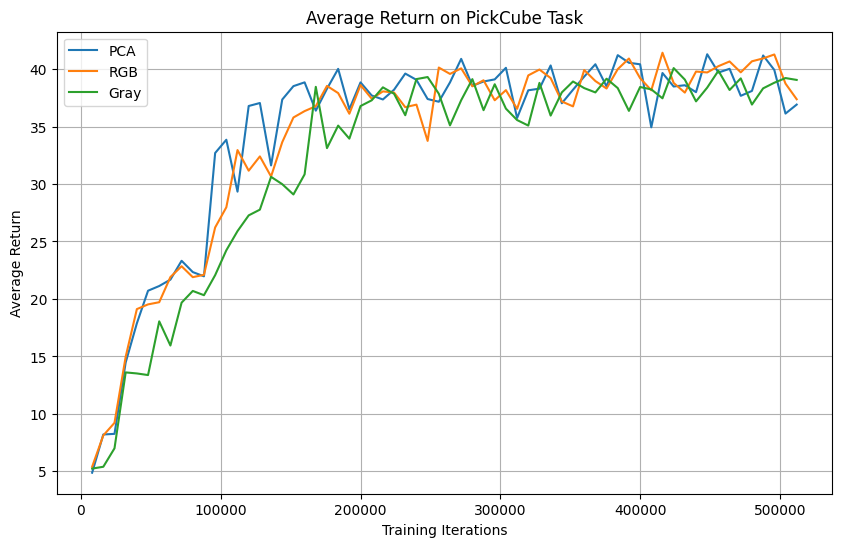

In [ ]:
import numpy as np
from scipy import stats

rgb_returns = []
pose_returns = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_returns.append(df['avg_return'].values)
        elif 'rgb' in trial_name:
            rgb_returns.append(df['avg_return'].values)
if pose_returns:
    pose_return_array = np.stack(pose_returns, axis=1)
    n = pose_return_array.shape[1]
    pose_mean = np.mean(pose_return_array, axis=1)
    pose_sem = stats.sem(pose_return_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='Pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if rgb_returns:
    rgb_return_array = np.stack(rgb_returns, axis=1)
    n = rgb_return_array.shape[1]
    rgb_mean = np.mean(rgb_return_array, axis=1)
    rgb_sem = stats.sem(rgb_return_array, axis=1)
    rgb_ci = rgb_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], rgb_mean, label='RGB')
    plt.fill_between(df['step'], rgb_mean - rgb_ci, rgb_mean + rgb_ci, alpha=0.3)
plt.title(f'Average Return')
plt.xlabel('Training Iterations')
plt.ylabel('Average Return')
plt.legend()
plt.grid()
plt.show()

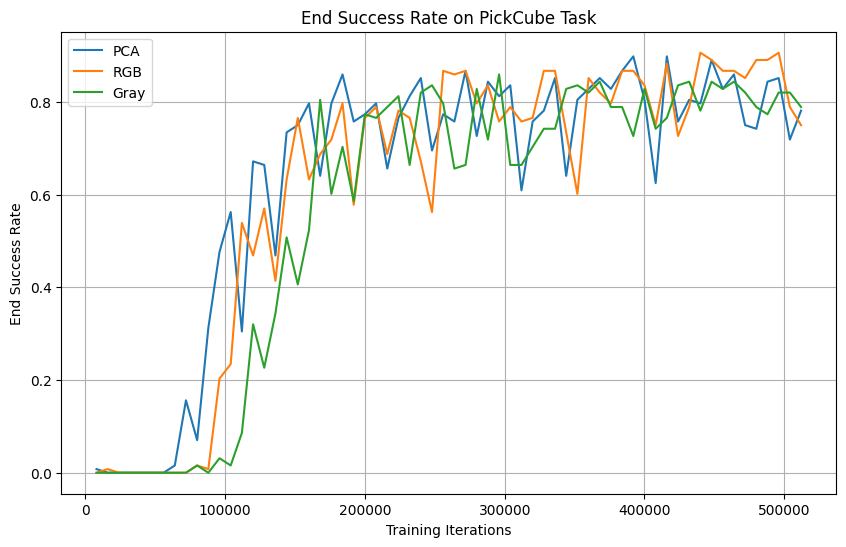

In [ ]:
pose_end_success = []
rgb_end_success = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_end_success.append(df['success_rate'].values)
        elif 'rgb' in trial_name:
            rgb_end_success.append(df['success_rate'].values)
if pose_end_success:
    pose_end_success_array = np.stack(pose_end_success, axis=1)
    n = pose_end_success_array.shape[1]
    pose_mean = np.mean(pose_end_success_array, axis=1)
    pose_sem = stats.sem(pose_end_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if rgb_end_success:
    rgb_end_success_array = np.stack(rgb_end_success, axis=1)
    n = rgb_end_success_array.shape[1]
    rgb_mean = np.mean(rgb_end_success_array, axis=1)
    rgb_sem = stats.sem(rgb_end_success_array, axis=1)
    rgb_ci = rgb_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], rgb_mean, label='RGB')
    plt.fill_between(df['step'], rgb_mean - rgb_ci, rgb_mean + rgb_ci, alpha=0.3)
plt.title(f'End Success Rate')
plt.xlabel('Training Iterations')
plt.ylabel('End Success Rate')
plt.legend()
plt.grid()
plt.show()

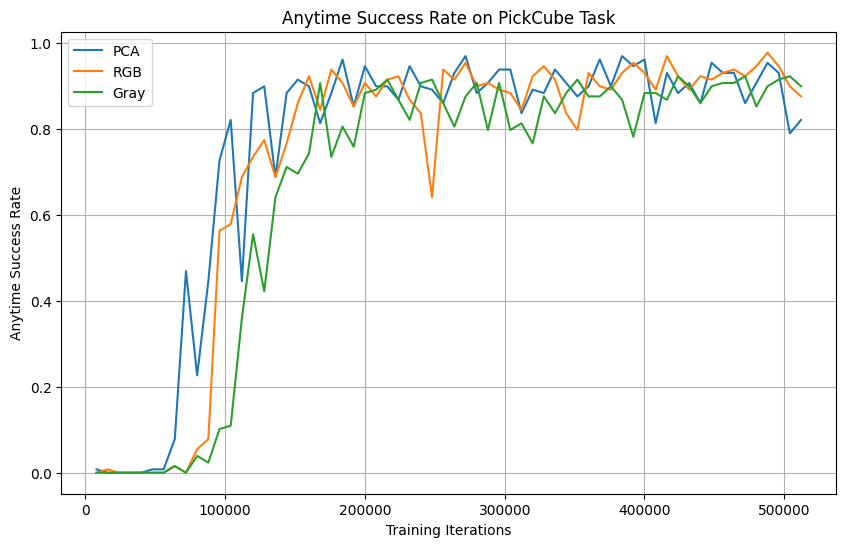

In [ ]:
pose_anytime_success = []
rgb_anytime_success = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_anytime_success.append(df['anytime_success_rate'].values)
        elif 'rgb' in trial_name:
            rgb_anytime_success.append(df['anytime_success_rate'].values)
if pose_anytime_success:
    pose_anytime_success_array = np.stack(pose_anytime_success, axis=1)
    n = pose_anytime_success_array.shape[1]
    pose_mean = np.mean(pose_anytime_success_array, axis=1)
    pose_sem = stats.sem(pose_anytime_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], pose_mean, label='pose')
    plt.fill_between(df['step'], pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if rgb_anytime_success:
    rgb_anytime_success_array = np.stack(rgb_anytime_success, axis=1)
    n = rgb_anytime_success_array.shape[1]
    rgb_mean = np.mean(rgb_anytime_success_array, axis=1)
    rgb_sem = stats.sem(rgb_anytime_success_array, axis=1)
    rgb_ci = rgb_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    plt.plot(df['step'], rgb_mean, label='RGB')
    plt.fill_between(df['step'], rgb_mean - rgb_ci, rgb_mean + rgb_ci, alpha=0.3)
plt.title(f'Anytime Success Rate')
plt.xlabel('Training Iterations')
plt.ylabel('Anytime Success Rate')
plt.legend()
plt.grid()
plt.show()

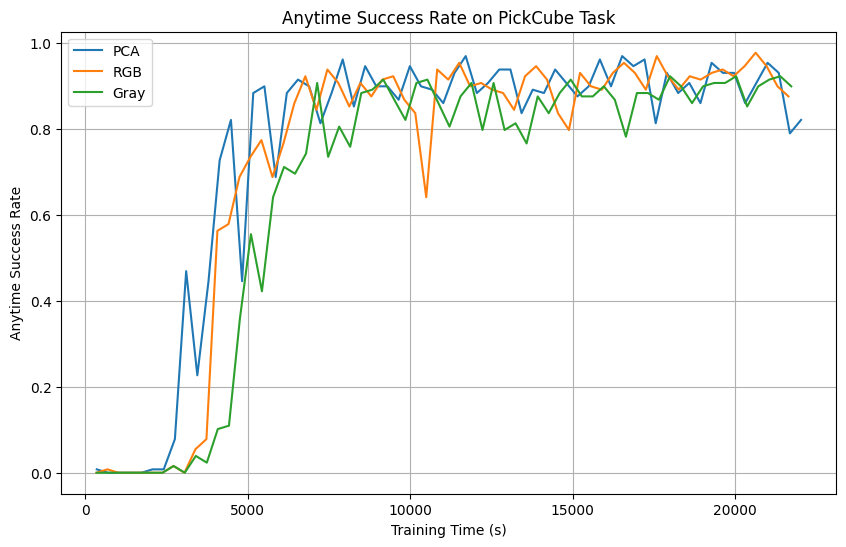

In [ ]:
pose_anytime_success = []
pose_wall_times = []
rgb_anytime_success = []
rgb_wall_times = []
plt.figure(figsize=(10, 6))
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_anytime_success.append(df['anytime_success_rate'].values)
            pose_wall_times.append(df['wall_time_s'].values)
        elif 'rgb' in trial_name:
            rgb_anytime_success.append(df['anytime_success_rate'].values)
            rgb_wall_times.append(df['wall_time_s'].values)
if pose_anytime_success:
    pose_anytime_success_array = np.stack(pose_anytime_success, axis=1)
    n = pose_anytime_success_array.shape[1]
    pose_mean = np.mean(pose_anytime_success_array, axis=1)
    pose_sem = stats.sem(pose_anytime_success_array, axis=1)
    pose_ci = pose_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    pose_wall_times_array = np.stack(pose_wall_times, axis=1)
    pose_wall_times_mean = np.mean(pose_wall_times_array, axis=1)
    plt.plot(pose_wall_times_mean, pose_mean, label='pose')
    plt.fill_between(pose_wall_times_mean, pose_mean - pose_ci, pose_mean + pose_ci, alpha=0.3)
if rgb_anytime_success:
    rgb_anytime_success_array = np.stack(rgb_anytime_success, axis=1)
    n = rgb_anytime_success_array.shape[1]
    rgb_mean = np.mean(rgb_anytime_success_array, axis=1)
    rgb_sem = stats.sem(rgb_anytime_success_array, axis=1)
    rgb_ci = rgb_sem * stats.t.ppf((1 + 0.95) / 2., n - 1)
    rgb_wall_times_array = np.stack(rgb_wall_times, axis=1)
    rgb_wall_times_mean = np.mean(rgb_wall_times_array, axis=1)
    plt.plot(rgb_wall_times_mean, rgb_mean, label='RGB')
    plt.fill_between(rgb_wall_times_mean, rgb_mean - rgb_ci, rgb_mean + rgb_ci, alpha=0.3)
plt.title(f'Anytime Success Rate on {task} Task')
plt.xlabel('Mean Training Time (s)')
plt.ylabel('Anytime Success Rate')
plt.legend()
plt.grid()
plt.show()

In [ ]:
pose_action_times = []
rgb_action_times = []
for trial_name, trial_dfs in trials.items():
    for df in trial_dfs:
        if 'pose' in trial_name:
            pose_action_times.append(df['avg_action_time_ms'].values)
        elif 'rgb' in trial_name:
            rgb_action_times.append(df['avg_action_time_ms'].values)
pose_action_times_array = np.concatenate(pose_action_times)
rgb_action_times_array = np.concatenate(rgb_action_times)
pose_mean_action_time = np.mean(pose_action_times_array)
rgb_mean_action_time = np.mean(rgb_action_times_array)
pose_action_time_ci = stats.sem(pose_action_times_array) * stats.t.ppf((1 + 0.95) / 2., len(pose_action_times_array) - 1)
rgb_action_time_ci = stats.sem(rgb_action_times_array) * stats.t.ppf((1 + 0.95) / 2., len(rgb_action_times_array) - 1)
print(f'Single-Cam Pose Mean Action Time: {pose_mean_action_time:.2f} ms ± {pose_action_time_ci:.2f} ms')
print(f'Single-Cam RGB Mean Action Time: {rgb_mean_action_time:.2f} ms ± {rgb_action_time_ci:.2f} ms')

Single-Cam PCA Mean Action Time: 1.10 ms ± 0.01 ms
Single-Cam Gray Mean Action Time: 1.04 ms ± 0.00 ms
Single-Cam RGB Mean Action Time: 1.03 ms ± 0.00 ms
